## Importación de librerías

In [2]:
#Tratamiento de datos
import numpy as np
import pandas as pd
#Visualizaciones
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('../data/raw/autorenew.csv', parse_dates=['dateCrawled', 'dateCreated', 'lastSeen']) 

In [4]:
df.head()

,dateCrawled,name,seller,offerType,price,vehicleType,yearOfRegistration,gearbox,powerCV,model,kilometer,monthOfRegistration,fuelType,brand,notRepairedDamage,dateCreated,nrOfPictures,postalCode,lastSeen
0,2016-03-24 11:52:17,Golf_3_1.6,private,offer,480,NaN,1993,manually,0.0,golf,150000,0,petrol,volkswagen,NaN,2016-03-24,0,70435,2016-04-07 03:16:57
1,2016-03-24 10:58:45,A5_Sportback_2.7_Tdi,private,offer,18300,coupe,2011,manually,187.0,NaN,125000,5,diesel,audi,yes,2016-03-24,0,66954,2016-04-07 01:46:50
2,2016-03-14 12:52:21,"Jeep_Grand_Cherokee_""Overland""",private,offer,9800,suv,2004,automatic,161.0,grand,125000,8,diesel,jeep,NaN,2016-03-14,0,90480,2016-04-05 12:47:46
3,2016-03-17 16:54:04,GOLF_4_1_4__3TÜRER,private,offer,1500,small car,2001,manually,74.0,golf,150000,6,petrol,volkswagen,no,2016-03-17,0,91074,2016-03-17 17:40:17
4,2016-03-31 17:25:20,Skoda_Fabia_1.4_TDI_PD_Classic,private,offer,3600,small car,2008,manually,68.0,fabia,90000,7,diesel,skoda,no,2016-03-31,0,60437,2016-04-06 10:17:21


## Selección columnas

Vamos a eliminar columnas que no nos aporten informacion relevante:

- `dateCrawled`, `dateCreated`, `lastSeen`: En el EDA preliminar habiamos visto que los anuncios son de entre 2014 y 2016 y que mas alla de eso no nos aporta mas informacion.

- `seller`: Todos los valores son private salvo 3 entradas, que son commercial. Vamos a eliminar directamente la columna.

- `offerType`: De igual forma, todos los valores son `offer` salvo 12 entradas, que son `request`. Podemos eliminar la columna y los vehiculos que son `request`.

- `model`: Tenemos mas de 250 categorias y es una subcategoria de `brand`. Podriamos dejarla para un analisis mas granular pero ahora vamos a eliminarla.

- `monthOfRegistration`: Podriamos hacer un analisis de estacionalidad o por temporadas, pero no sera el caso. Ademas, hay un valor que es 0, lo cual es 
imposible para meses por lo que realmente seria desconocido. Utilizaremos solamente `year0fRegistration`.

- `nrOfPictures`: Todos los valores son 0 por lo que no aporta valor.

- `postalCode`: Esta variable corresponde a codigos postales y podría tratarse como categorica. Sin embargo, no nos aporta mucha informacion que nos resulte útil, por ello decidimos eliminarla.

### Eliminar duplicados

In [5]:
df = df.drop_duplicates()

In [6]:
columnas_eliminar = [
  'dateCrawled', 
  'dateCreated', 
  'lastSeen', 
  'seller',
  'offerType',
  'model',
  'monthOfRegistration',
  'nrOfPictures',
  'postalCode'
  ]

In [7]:
df = df.drop(columns=columnas_eliminar)

In [8]:
df.duplicated().mean()*100

3.1281962941828794

Fijemonos en que ahora puede haber duplicados ya que ahora pueden ser diferentes unidades del mismo vehículo. En este caso no tenemos forma de saber se es el mismo o diferente ya que no tenemos un identificador único (`name` puede ser el mismo), así que los vamos a dejar por si acaso.

## Limpieza de datos

Vamos a hacer una limpieza columna a columna.

In [9]:
df.columns

Index(['name', 'price', 'vehicleType', 'yearOfRegistration', 'gearbox',
       'powerCV', 'kilometer', 'fuelType', 'brand', 'notRepairedDamage'],
      dtype='object')

### Columna `price`

Valores de precio extremadamente bajos no tienen sentido. Sin embargo, es dificil establecer un criterio estricto para filtrar ya que vehiculos muy antiguos o con danos realmente pueden tener precios muy bajos.

In [10]:
print(f"El porcentaje de valores nulos en la columna price es: {df['price' ]. isna( ). sum() }")

El porcentaje de valores nulos en la columna price es: 0


Como no teníamos valores nulos, veamos qué proporción de vehículos tienen un valor inferior a cierto umbral. Podemos elegir el umbral por ejemplo 100 (presumiblemente en euros).

In [11]:
umbral_precio_inferior = 100
porcentaje_baratos = (df['price'] < umbral_precio_inferior).mean() * 100

print(f"El porcentaje de vehículos por debajo de {umbral_precio_inferior} es: {round(porcentaje_baratos, 2)}%")

El porcentaje de vehículos por debajo de 100 es: 3.59%


Los datos con un precio inferior a 100 son muy probablemente erroneos y representan alrededor del 3,6% del conjunto de datos, por lo que parece razonable eliminarlos.
Es posible que haya vehiculos que realmente tengan un precio por debajo de 100 debido a danos no reparados o a su antiguedad, pero es dificil establecer este criterio, asi que
procederemos de esta manera.

Veamos ahora que sucede con los vehiculos con un precio muy elevado. Pongamos el umbral en 4M.

In [12]:
umbral_precio_superior = 4e6 #Equivalente a 4 millones de euros

porcentaje_caros = (df ['price'] > umbral_precio_superior).mean() * 100

print(f"El porcentaje de vehiculos por encima de {umbral_precio_superior} es: {porcentaje_caros:.3f}%")

El porcentaje de vehiculos por encima de 4000000.0 es: 0.014%


Podemos revisar manualmente estos datos para comprobar si tienen sentido:

In [13]:
df[df['price'] > umbral_precio_superior].sample(5)

,name,price,vehicleType,yearOfRegistration,gearbox,powerCV,kilometer,fuelType,brand,notRepairedDamage
347435,Schlachte_Golf_4_1.4_16_fast_alles_noch_da,9999999,NaN,2000,manually,74.0,150000,petrol,volkswagen,yes
39625,Tausche_volvo_v40_gegen_van,12345678,NaN,2018,manually,94.0,150000,NaN,volvo,no
338415,Polo_6n_gti__Zustand_egal_,11111111,NaN,2000,NaN,118.0,125000,petrol,volkswagen,NaN
210657,Escort_MK_1_Hundeknochen_zum_umbauen_auf_RS_2000,11111111,NaN,1973,manually,47.0,50000,petrol,ford,no
246635,Suche_Vw_Passat..........,99999999,NaN,2000,NaN,0.0,5000,NaN,volkswagen,NaN


Tras revisar los datos, podemos concluir que todos los precios superiores a 4 millones corresponden a registros erróneos.

Por lo tanto, filtramos los datos por precios de esta forma:

In [14]:
filtro_precio = (df['price'] > umbral_precio_inferior) & (df['price'] <= umbral_precio_superior)
df = df[filtro_precio]

### Columna `yearOfRegistration`

Tal y como vimos con las columnas de fechas de los anuncios, los registros no pueden ser de después de 2016. Sin embargo, vamos a comprobar las entradas posteriores a este año.

In [15]:
df[df['yearOfRegistration'] > 2016]['yearOfRegistration'].value_counts().head()

yearOfRegistration
2017    9925
2018    3797
2019      15
9999      14
5000      14
Name: count, dtype: int64

Vemos que hay unas cuantas entradas en 2017 y 2018, por lo que vamos a mantenerlas ya que es posible que las columnas de fechas que habiamos eliminado posiblemente fuesen las que estaban mal.

El resto de años son mucho menos frecuentes y la mayoria no tienen sentido por lo que podemos asumir que son errores y eliminarlos o etiquetarlos como nulos.

In [16]:
# Nos quedamos con las entradas que sean anteriores a 2019 (el umbral de anos que hemos establecido)
df = df[df['yearOfRegistration'] < 2019]

Veamos ahora que ocurre con vehiculos con fechas de registro muy antiguas. Por ejemplo, establezcamos el umbral en 1950

In [17]:
umbral_fecha = 1950
df [df['yearOfRegistration'] < umbral_fecha] ['yearOfRegistration'].value_counts().head()

yearOfRegistration
1910    36
1000    23
1937    12
1938     8
1929     7
Name: count, dtype: int64

Vemos que tenemos 36 entradas de 1910, que seguramente sean errores (por la fecha de invención del coche). Veamos la distribución gráfica más detallada.

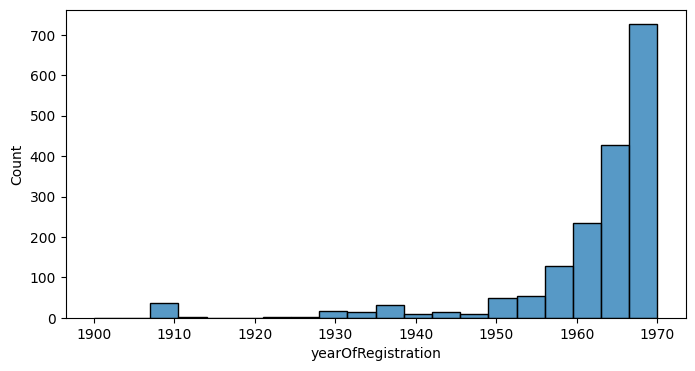

In [18]:
plt.figure(figsize=(8,4))

sns.histplot(df['yearOfRegistration'], bins=20, binrange=(1900, 1970))
plt.show()

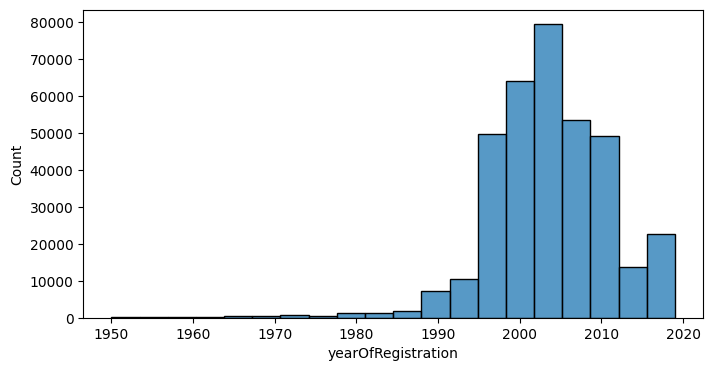

In [19]:
plt.figure(figsize=(8,4))

sns.histplot(df['yearOfRegistration'], bins=20, binrange=(umbral_fecha, 2019))
plt.show()

Podemos examinar individualmente las entradas de vehículos más antiguos para ver si genuinamente son errores

In [20]:
df [df['yearOfRegistration'] < umbral_fecha].sample(5)

,name,price,vehicleType,yearOfRegistration,gearbox,powerCV,kilometer,fuelType,brand,notRepairedDamage
142497,Ausschankwagen,16500,NaN,1000,NaN,0.0,5000,NaN,sonstige_autos,NaN
59830,Suche_Fahrzeug_mit_Anhaengerkupplung_und_LPG_G...,1000,NaN,1910,NaN,0.0,150000,NaN,sonstige_autos,NaN
19125,Subaru_Impreza_Wrx_2.0,7999,NaN,1500,manually,221.0,5000,NaN,subaru,NaN
232534,VW_LT_28_Benzin_steuergeraet_defekt,1500,NaN,1039,NaN,0.0,5000,petrol,volkswagen,NaN
370654,Mercedes_Benz_170V___Vorkriegsmodell,6000,NaN,1937,manually,37.0,5000,petrol,mercedes_benz,NaN


Vemos que la mayoría de estas entradas parecen ser erróneas por lo que directamente aplicaremos filtro para eliminarlas.

Tambien podríamos convertir su año a un valor nulo y luego gestionarlos, pero al tener poca información y ser pocas entradas del dataset no nos compensa.

In [21]:
# Nos quedamos con las entradas que sean posteriores a 1950 (el umbral de anos que hemos establecido)
df = df[df['yearOfRegistration'] > umbral_fecha]

### Columna `powerCV`

Un vehículo con una potencia de mas de 1200 CV practicamente no existe, y menos aun que se venda de segunda mano. Estos valores seran convertidos a nulos.
Por otra parte, es muy poco frecuente tener vehiculos en el rango de entre 750CV y 1200CV, incluso siendo deportivos. Vamos a ver la distribucion en este rango.

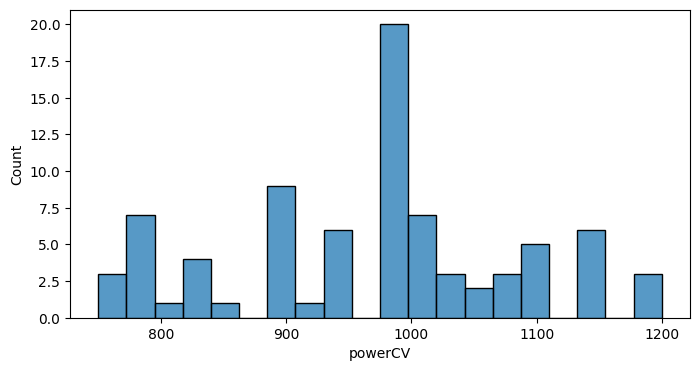

In [22]:
umbral_superior_cv = 750

plt.figure(figsize=(8, 4))

sns.histplot(df['powerCV'], bins=20, binrange=(umbral_superior_cv, 1200))
plt. show()

In [23]:
df[df['powerCV'] > umbral_superior_cv].shape

(317, 10)

In [24]:
df[df['powerCV'] > umbral_superior_cv].sample(5)

,name,price,vehicleType,yearOfRegistration,gearbox,powerCV,kilometer,fuelType,brand,notRepairedDamage
293035,Mercedes_E220_CDI,1550,NaN,2016,manually,910.0,150000,NaN,mercedes_benz,no
211669,Daewoo_Nubira_PKW_TÜV/neu!,1590,other,2004,manually,1576.0,150000,petrol,daewoo,NaN
335535,Renault_Clio,2995,small car,2005,manually,7426.0,150000,petrol,renault,NaN
324266,Golf_4_1;4,950,small car,1998,manually,7408.0,150000,petrol,volkswagen,no
148628,Passat_Limousine_nicht_fahrbereit,600,NaN,1997,manually,5924.0,150000,petrol,volkswagen,yes


In [25]:
#Nos quedamos con las entradas que tengan potencia inferior al umbral de 750 CV
df[df['powerCV'] < umbral_superior_cv]

,name,price,vehicleType,yearOfRegistration,gearbox,powerCV,kilometer,fuelType,brand,notRepairedDamage
0,Golf_3_1.6,480,NaN,1993,manually,0.0,150000,petrol,volkswagen,NaN
1,A5_Sportback_2.7_Tdi,18300,coupe,2011,manually,187.0,125000,diesel,audi,yes
2,"Jeep_Grand_Cherokee_""Overland""",9800,suv,2004,automatic,161.0,125000,diesel,jeep,NaN
3,GOLF_4_1_4__3TÜRER,1500,small car,2001,manually,74.0,150000,petrol,volkswagen,no
4,Skoda_Fabia_1.4_TDI_PD_Classic,3600,small car,2008,manually,68.0,90000,diesel,skoda,no
...,...,...,...,...,...,...,...,...,...,...
371523,Suche_t4___vito_ab_6_sitze,2200,NaN,2005,NaN,0.0,20000,NaN,sonstige_autos,NaN
371524,Smart_smart_leistungssteigerung_100ps,1199,convertible,2000,automatic,100.0,125000,petrol,smart,no
371525,Volkswagen_Multivan_T4_TDI_7DC_UY2,9200,bus,1996,manually,101.0,150000,diesel,volkswagen,no
371526,VW_Golf_Kombi_1_9l_TDI,3400,combi,2002,manually,99.0,150000,diesel,volkswagen,NaN


En cuanto al rango inferior de potencia, los vehiculos con potencia inferior a cierto valor no son realistas. Los vehiculos menos potentes del mercado pueden llegar hasta 50CV. Pongam un umbral de 30CV, para permitir la posibilidad de de que vehiculos mas antiguos o modestos puedan llegar a niveles mas bajos.
Veamos algunas entradas:


In [26]:
df[df['powerCV'] < 30].shape[0]

35887

Vemos que hay muchas con un valor de 0 o valores que no tienen sentido. Como son bastantes entradas no las vamos a eliminar sino reemplazarlas por valores nulos

In [27]:
# Generar nulos para estos valores
df['powerCV'] = df ['powerCV']. apply(lambda x: np.nan if x < 40 else x)

### Columna `kilometer`

Los km acumulados por un vehículo es una variable numérica continua. Sin embargo, los datos parecen estar agrupados en intervalos discretos. 

In [30]:
df['kilometer'].value_counts()

kilometer
150000    230729
125000     37163
100000     15325
90000      12301
80000      10859
70000       9638
60000       8569
50000       7510
40000       6307
30000       5901
20000       5469
5000        5278
10000       1774
Name: count, dtype: int64

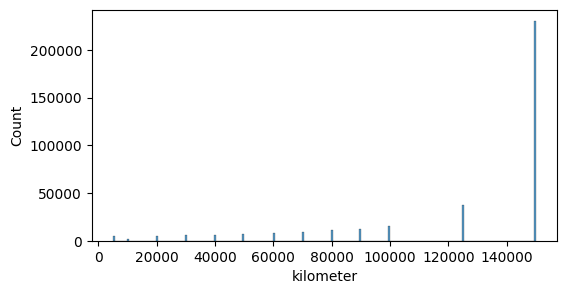

In [31]:
plt.figure(figsize=(6, 3))
sns.histplot(df['kilometer'])
plt.show()

No parece haber ningún valor que sea extraño por lo que vamos a dejarlo como está 

### Columna `vehicleType`

In [32]:
df['vehicleType'].value_counts(dropna=False)

vehicleType
NaN            125801
small car       77200
combi           65773
bus             29677
convertible     22469
coupe           18362
suv             14451
other            3090
Name: count, dtype: int64

In [33]:
df['vehicleType'].isna().mean() * 100

35.255855143866846

vemos que tenemos 7 tipos de valores diferentes con una gran cantidad de nulos. Podemos directamente crear una nueva categoría que sea `unknown`

In [34]:
df['vehicleType'] =df['vehicleType'].fillna('unknown')

In [35]:
df['vehicleType'].value_counts()

vehicleType
unknown        125801
small car       77200
combi           65773
bus             29677
convertible     22469
coupe           18362
suv             14451
other            3090
Name: count, dtype: int64

### Columna `gearbox`

In [36]:
df['gearbox'].value_counts(dropna=False)

gearbox
manually     265106
automatic     75414
NaN           16303
Name: count, dtype: int64

In [40]:
df['gearbox'] = df['gearbox'].fillna('unknown')

In [38]:
df['gearbox'].value_counts()

gearbox
manually     265106
automatic     75414
unknown       16303
Name: count, dtype: int64

### Columna `fuelType`

In [39]:
df['fuelType'].value_counts(dropna=False)

fuelType
petrol     216273
diesel     105913
NaN         28337
lpg          5221
cng           553
hybrid        271
other         155
electro       100
Name: count, dtype: int64

In [41]:
df['fuelType'] = df['fuelType'].fillna('unknown')

In [43]:
df['fuelType'].value_counts()

fuelType
petrol     216273
diesel     105913
unknown     28337
lpg          5221
cng           553
hybrid        271
other         155
electro       100
Name: count, dtype: int64

Vemos que casi todos son gasolina o diésel. Unos cuantos son desconocidos y hay una pequeña proporción del resto de categorías.

### Columna `brand`

In [44]:
df['brand'].unique()

array(['volkswagen', 'audi', 'jeep', 'skoda', 'bmw', 'peugeot', 'ford',
       'mazda', 'nissan', 'renault', 'mercedes_benz', 'opel', 'seat',
       'citroen', 'honda', 'fiat', 'mini', 'smart', 'hyundai',
       'alfa_romeo', 'subaru', 'volvo', 'mitsubishi', 'kia', 'suzuki',
       'lancia', 'porsche', 'sonstige_autos', 'toyota', 'chevrolet',
       'dacia', 'daihatsu', 'chrysler', 'jaguar', 'daewoo', 'rover',
       'saab', 'land_rover', 'trabant', 'lada'], dtype=object)

Fijémonos que 'sonstige_autos' se traduce del alemán como 'otros_vehículos', por lo que podemos modificarlo a 'other', para facilitar la comprensión.

In [45]:
df['brand'].isna().sum()

0

In [46]:
df['brand'].replace({'sonstige_autos': 'other'}).unique()

array(['volkswagen', 'audi', 'jeep', 'skoda', 'bmw', 'peugeot', 'ford',
       'mazda', 'nissan', 'renault', 'mercedes_benz', 'opel', 'seat',
       'citroen', 'honda', 'fiat', 'mini', 'smart', 'hyundai',
       'alfa_romeo', 'subaru', 'volvo', 'mitsubishi', 'kia', 'suzuki',
       'lancia', 'porsche', 'other', 'toyota', 'chevrolet', 'dacia',
       'daihatsu', 'chrysler', 'jaguar', 'daewoo', 'rover', 'saab',
       'land_rover', 'trabant', 'lada'], dtype=object)

### Columna `notRepairedDamage`

In [67]:
df['notRepairedDamage'].value_counts(dropna=False)

notRepairedDamage
no     258961
NaN     64571
yes     33291
Name: count, dtype: int64

Volvemos a cambiar los valores nulos por 'unknown'

In [70]:
df['notRepairedDamage'] = df['notRepairedDamage'].fillna('unknown')

In [71]:
df['notRepairedDamage'].value_counts()

notRepairedDamage
no         258961
unknown     64571
yes         33291
Name: count, dtype: int64

##Guardamos el dataset limpio

In [72]:
df.to_csv('../data/output/autorenew_limpio.csv', index=False)